In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
full_df = pd.read_csv("umn_apartment_data.csv")

In [35]:
df = full_df.iloc[:,:9]
amenities_df = full_df.iloc[:,9:]

temp_df = pd.DataFrame()
for index, values in amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True)

df = pd.concat([df, temp_df], axis = 1, ignore_index = True)

column_list = ["Name", "Address", "Floor Plan", "Bedrooms", "Bathrooms", "Price", "Size", "Availability", "Link", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[df.columns.values[i]] = column_list[i]

df = df.rename(columns = column_dic)
df

,Name,Address,Floor Plan,Bedrooms,Bathrooms,Price,Size,Availability,Link,Amenities
0,The Quad on Delaware,D1R - Renovated 4 Bedroom 4 Bath,2508 Delaware Street SE Minneapolis MN 55414,4,4.0,$639.00,1239,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[Garbage Disposal, Parking Available, 24 Hour ..."
1,The Quad on Delaware,D1 - 4 Bedroom 4 Bath,2508 Delaware Street SE Minneapolis MN 55414,4,4.0,$599.00,1239,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[Garbage Disposal, Parking Available, 24 Hour ..."
2,The Quad on Delaware,C1 - 3 Bedroom 3 Bath,2508 Delaware Street SE Minneapolis MN 55414,3,3.0,$669.00,1035,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[Garbage Disposal, Parking Available, 24 Hour ..."
3,The Quad on Delaware,C1R - Renovated 3 Bedroom 3 Bath,2508 Delaware Street SE Minneapolis MN 55414,3,3.0,$719.00,1035,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[Garbage Disposal, Parking Available, 24 Hour ..."
4,The Quad on Delaware,B1 - 2 Bedroom 2 Bath,2508 Delaware Street SE Minneapolis MN 55414,2,2.0,$849.00,806,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[Garbage Disposal, Parking Available, 24 Hour ..."
...,...,...,...,...,...,...,...,...,...,...
714,Accolade Minneapolis,S2,2650 University Ave SE Minneapolis MN 55414,Studio,1.0,$1320.00,391,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[Gated garage parking available]
715,Accolade Minneapolis,S3,2650 University Ave SE Minneapolis MN 55414,Studio,1.0,$1305.00,391,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[Gated garage parking available]
716,Accolade Minneapolis,S1 Affordable,2650 University Ave SE Minneapolis MN 55414,Studio,1.0,$1249.00,389,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[Gated garage parking available]
717,Thomas Place,4 Bedroom,624 University Ave SE. Minneapolis MN 55414,4,2.0,$635.00,1200,09-01-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[9 Foot Ceilings, Air Conditioning, Ample Clos..."


Potential Features:
- Location (Distance from a Central Point)
- Amount of Bathrooms/Beds
- Price
- Size
- Amenities (Specific ID for Each Kind)
- Shaping (potentially)

In [36]:
df["Bedrooms"].unique()

array(['4', '3', '2', '1', '10', '5', 'Studio', '6'], dtype=object)

In [37]:
idx = 0
for value in df["Bedrooms"]:
    if value.strip() == "Studio":
        df.iloc[idx, 3] = "0"
    else:
        df.iloc[idx, 3] = value[0]
    idx += 1

In [38]:
idx = 0
for value in df["Bathrooms"]:
    df.iloc[idx, 4] = value[0]
    idx += 1

TypeError: 'float' object is not subscriptable

In [39]:
idx = 0
for value in df["Price"]:
    df.iloc[idx, 5] = value[1:]
    idx += 1

In [40]:
idx = 0
for value in df["Size"]:
    df.iloc[idx, 6] = value[:4]
    idx += 1

TypeError: 'float' object is not subscriptable

In [ ]:
df["Size"][:80]

array(['389 ', '391 ', '558 ', '559 ', '683 ', '949 ', '886 ', '801 ',
       '838 ', '776 ', '894 ', '1283', '460 ', '442 ', '417 ', '613 ',
       '624 ', '777 ', '800 ', '806 ', '1035', '1239', '850 ', '685 ',
       '780 ', '1420', '1423', '1107', '1495', '585 ', '673 ', '769 ',
       '787 ', '900 ', '1344', '1143', '1325', '1536', '1542', '1665',
       '1656', '1298', '1638', '1576', '1473', '1234', '2317', '1460',
       '1997', '1967', '468 ', '467 ', '583 ', '477 ', '515 ', '625 ',
       '675 ', '633 ', '611 ', '606 ', '674 ', '693 ', '767 ', '803 ',
       '975 ', '1070', '870 ', '865 ', '917 ', '853 ', '910 ', '486 ',
       '1153', '994 ', '1047', '1116', '882 ', '1380', '1457', '1314'],
      dtype=object)

In [22]:
df["Price"][:80]

0     1180
1     1180
2     1249
3     1305
4     1429
      ... 
75    1539
76    1569
77    1569
78    1639
79    1679
Name: Price, Length: 80, dtype: object

TypeError: 'value' must be an instance of str or bytes, not a float

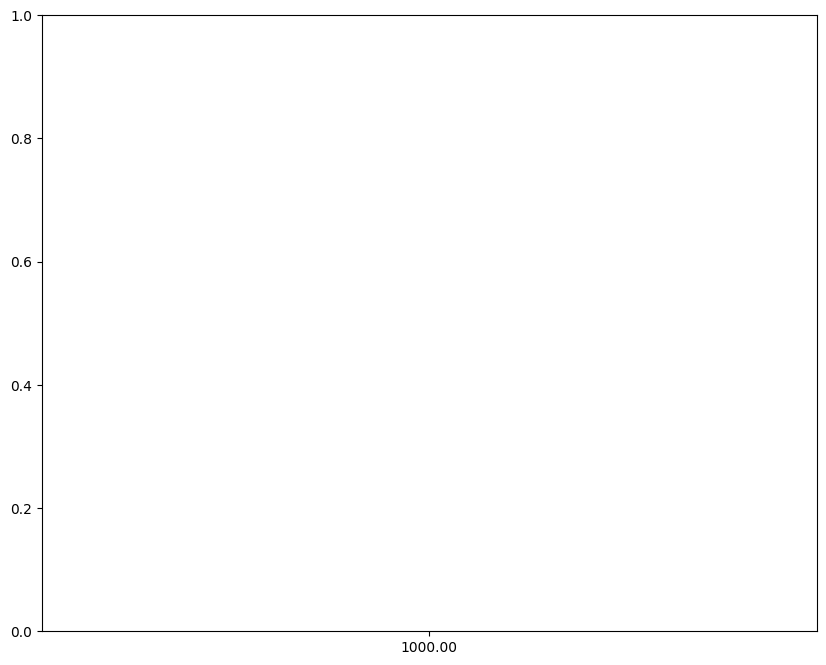

In [41]:
gs, ax = plt.subplots(figsize = (10,8))

plt.scatter(df.sort_values("Price")["Price"], df.sort_values("Price")["Size"])
plt.xticks(["1000", "1500", "2000"])


In [42]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'], errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
df = df.dropna()

In [ ]:
print(df[["Price", "Size", "Bathrooms", "Bedrooms"]].cosrr())

              Price      Size  Bathrooms  Bedrooms
Price      1.000000  0.494084   0.162138  0.510139
Size       0.494084  1.000000   0.685443  0.777038
Bathrooms  0.162138  0.685443   1.000000  0.756518
Bedrooms   0.510139  0.777038   0.756518  1.000000
